# Discrete probability distributions

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Bernoulli

If we can imagine a random number between 0 and 1, we can make a rule for a Bernoulli

In [2]:
np.random.rand()

0.8730634209862493

In [3]:
p = 1/8 # parameter

np.random.rand()<p

False

Or some program (library) can do it for us

In [4]:
from scipy.stats import bernoulli

bernoulli.rvs(p=1/2, size=10)

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 1])

## Binomial

In [5]:
from scipy.special import comb

In [6]:
k = list(range(11))
print(k)

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]


<BarContainer object of 11 artists>

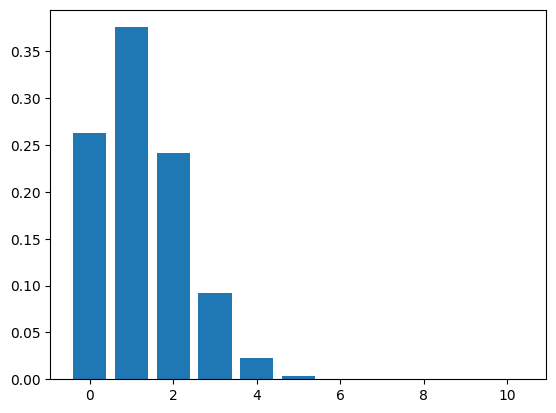

In [7]:
p = 1/8

plt.bar(k,[comb(10,x) * p**x * (1-p)**(10-x) for x in k])

$$ P(\text{3 successes and 7 failures}) = {10 \choose 3}  p^3 (1-p)^7$$


We can simulate using Bernoullis

In [8]:
p = 1/2 # parameter

np.random.rand()<p

False

In [9]:
np.random.rand(10)

array([0.80413254, 0.78500635, 0.53895338, 0.86712247, 0.25151545,
       0.44501094, 0.40809769, 0.14316682, 0.5236393 , 0.70142505])

In [10]:
p = 1/2 # parameter

np.random.rand(10)<p

array([False,  True, False,  True,  True, False,  True,  True, False,
        True])

In [11]:
p = 1/2 # parameter

# A binomial with parameters (10, p)
np.sum( np.random.rand(10)<p )

np.int64(5)

In [12]:
# 1000 binomials
binom_values = []

for i in range(1000):
  binom_values.append(np.sum( np.random.rand(10)<p ))

binom_values[0:10]

[np.int64(6),
 np.int64(8),
 np.int64(7),
 np.int64(5),
 np.int64(5),
 np.int64(5),
 np.int64(6),
 np.int64(3),
 np.int64(6),
 np.int64(6)]

(array([  0.,   8.,  47., 106., 237., 227., 197., 121.,  45.,  12.]),
 array([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10.]),
 <BarContainer object of 10 artists>)

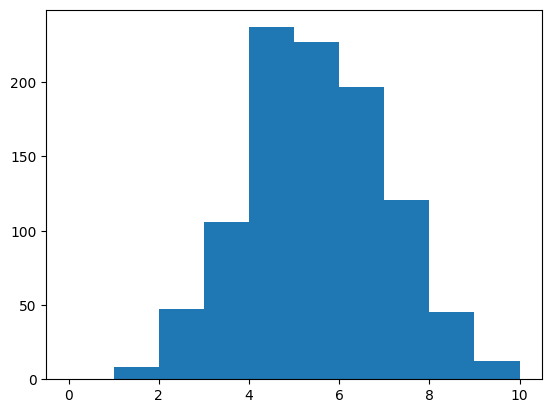

In [13]:
plt.hist(binom_values, bins=k)

Histogram vs probability function

In [14]:
from scipy.stats import binom

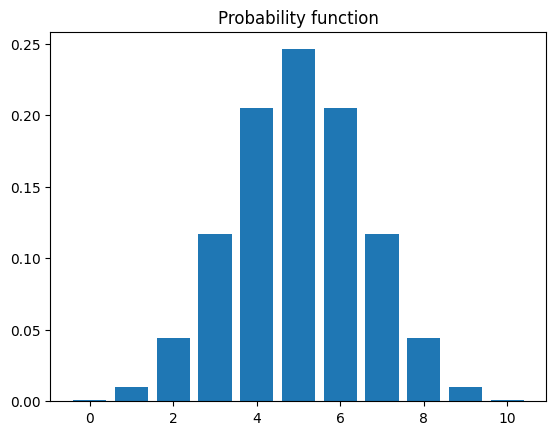

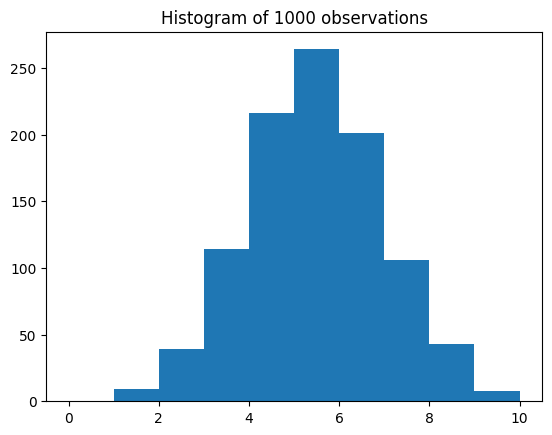

In [15]:
# Probability function

# parameters
p=1/2
n=10
############

k=list(range(n+1))

plt.bar(k,[comb(n,x) * p**x * (1-p)**(n-x) for x in k])
plt.title("Probability function")
plt.show()

# Histogram using 1000 observations
plt.hist(binom.rvs(n=n, p=p, size=1000), bins=k)
plt.title("Histogram of 1000 observations")
plt.show()

**Varying the parameters**

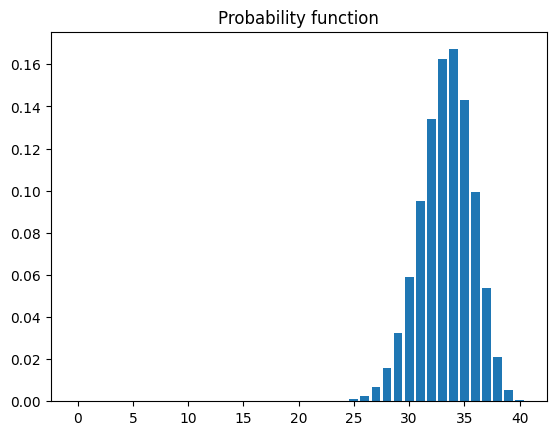

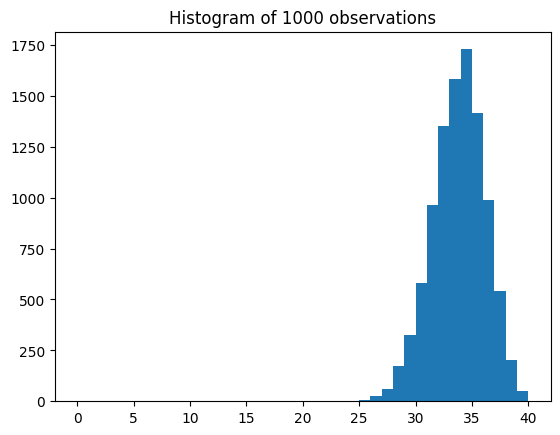

In [16]:
# Probability function

# parameters
p=5/6
n=40
############

k=list(range(n+1))

plt.bar(k,[comb(n,x) * p**x * (1-p)**(n-x) for x in k])
plt.title("Probability function")
plt.show()

# Histogram using 1000 observations
plt.hist(binom.rvs(n=n, p=p, size=10000), bins=k)
plt.title("Histogram of 1000 observations")
plt.show()

## Geometric

In [17]:
from scipy.stats import geom

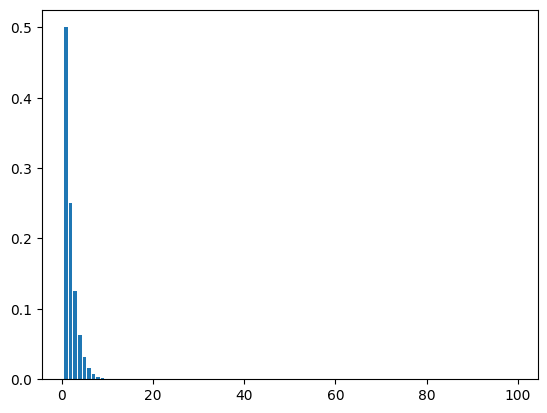

In [18]:
plt.bar(range(1,100), geom.pmf(range(1,100), p=1/2))
plt.show()

In [19]:
# several parameter options
p_various = [0.1,0.25,0.5,0.75,0.9]

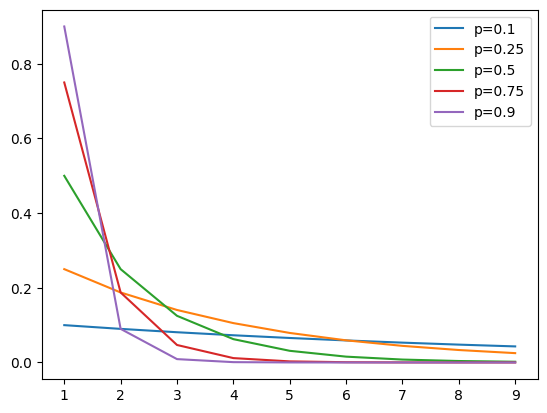

In [20]:
for p in p_various:
  plt.plot(range(1,10), geom.pmf(range(1,10), p=p), label=f'p={p}')
plt.legend()
plt.show()

## Negative binomial

In [21]:
from scipy.stats import nbinom

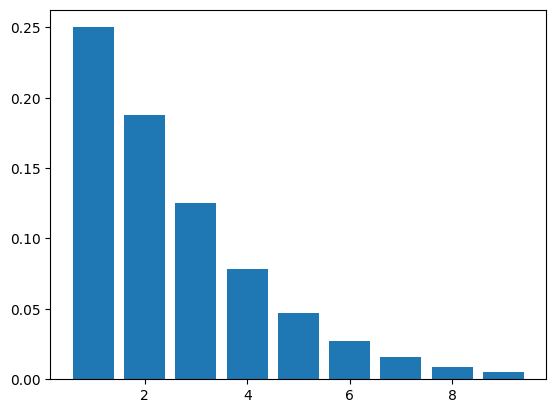

In [22]:
plt.bar(range(1,10), nbinom.pmf(range(1,10), p=1/2, n=2))
plt.show()

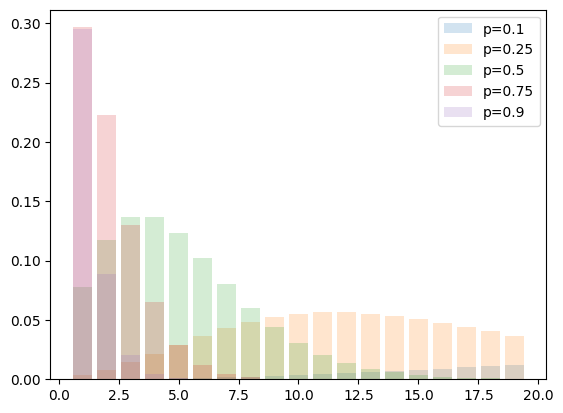

In [23]:
for p in p_various:
  plt.bar(range(1,20), nbinom.pmf(range(1,20), p=p, n=5), label=f'p={p}', alpha=0.2)
plt.legend()
plt.show()

### Expected value

The expected value of a discrete random variable is the weighted average of the values by their probability.

$$ E(f) = \sum_k k f(k) $$

This is a "center of gravity" of the distribution.

For example, in the **Binomial**

In [24]:
# parameters
n = 10
p = 1/2

# possible values
k = [0,1,2,3,4,5,6,7,8,9,10]

# probabilities of the values
probs = binom.pmf(k, n=n, p=p)
print(probs)

[0.00097656 0.00976563 0.04394531 0.1171875  0.20507812 0.24609375
 0.20507812 0.1171875  0.04394531 0.00976563 0.00097656]


In [25]:
# expected value
np.sum(k * probs)

np.float64(4.999999999999999)

Or for the **Bernoulli**

$$ \sum_k k p^k(1-p)^{1-k} = 1 * p^1 + 0 * (1-p)^0 = p$$

### Variance

The variance tells us how much the values deviate from the mean on average

# Continuous probability distributions

Points to discuss:

* What is the probability of a particular number?
* What is the expected value?
  - Is the average still valid?
* Histogram vs distribution


In [26]:
from scipy.stats import gamma

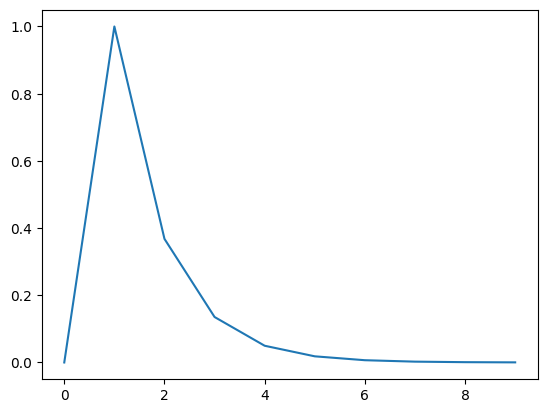

In [27]:
plt.plot(range(0,10), gamma.pdf(range(0,10),1,1))

(array([467., 245., 147.,  70.,  33.,  21.,   8.,   3.,   2.,   4.]),
 array([1.00066156, 1.64436504, 2.28806853, 2.93177201, 3.57547549,
        4.21917897, 4.86288246, 5.50658594, 6.15028942, 6.79399291,
        7.43769639]),
 <BarContainer object of 10 artists>)

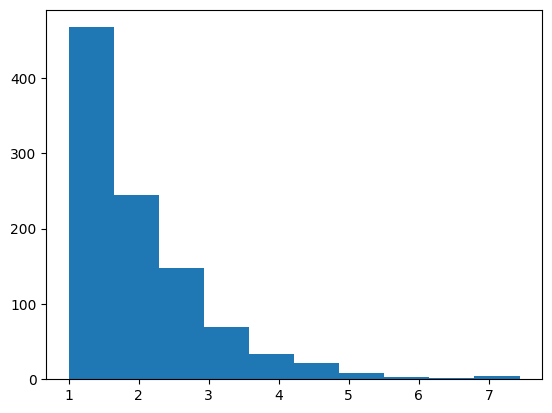

In [28]:
x = gamma.rvs(1,1,size=1000)
plt.hist(x)